In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/Dataset/Dataset /content/

In [ ]:
!ls /content/Dataset

best_efficientnet.pth  efficientnet_checkpoint.pth  F2	vgg16_checkpoint.pth
best_livxai_model.pth  F0			    F3
best_vgg16.pth	       F1			    F4


In [ ]:
import torch
import torchvision
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
device = torch.device("cpu")
print(device)

cpu


In [ ]:
transform = transforms.Compose([

    transforms.Resize((160,160)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.RandomResizedCrop(160),

    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    "/content/Dataset",
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 6323
Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Loaders ready")

Loaders ready


In [ ]:
model = torchvision.models.mobilenet_v2(pretrained=True)

model.classifier[1] = torch.nn.Linear(
    model.last_channel,
    5
)

model = model.to(device)

print("MobileNet loaded")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 97.7MB/s]

MobileNet loaded


In [ ]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003
)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    for batch_idx,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} Batch {batch_idx}/{len(train_loader)} Loss {loss.item():.4f}")

    print("Epoch finished\n")

Epoch 1/10 Batch 0/139 Loss 1.6222
Epoch 1/10 Batch 10/139 Loss 1.1356
Epoch 1/10 Batch 20/139 Loss 1.1360
Epoch 1/10 Batch 30/139 Loss 0.8214
Epoch 1/10 Batch 40/139 Loss 0.8555
Epoch 1/10 Batch 50/139 Loss 1.1352
Epoch 1/10 Batch 60/139 Loss 0.7507
Epoch 1/10 Batch 70/139 Loss 1.2497
Epoch 1/10 Batch 80/139 Loss 1.0084
Epoch 1/10 Batch 90/139 Loss 0.9219
Epoch 1/10 Batch 100/139 Loss 0.6868
Epoch 1/10 Batch 110/139 Loss 0.9008
Epoch 1/10 Batch 120/139 Loss 0.5590
Epoch 1/10 Batch 130/139 Loss 1.1156
Epoch finished

Epoch 2/10 Batch 0/139 Loss 0.9835
Epoch 2/10 Batch 10/139 Loss 1.1689
Epoch 2/10 Batch 20/139 Loss 0.6441
Epoch 2/10 Batch 30/139 Loss 0.6368
Epoch 2/10 Batch 40/139 Loss 0.7010
Epoch 2/10 Batch 50/139 Loss 1.0157
Epoch 2/10 Batch 60/139 Loss 0.7438
Epoch 2/10 Batch 70/139 Loss 0.6103
Epoch 2/10 Batch 80/139 Loss 0.9931
Epoch 2/10 Batch 90/139 Loss 0.9638
Epoch 2/10 Batch 100/139 Loss 0.9931
Epoch 2/10 Batch 110/139 Loss 0.8106
Epoch 2/10 Batch 120/139 Loss 0.5660
Epoch 2

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total

print("Test Accuracy:",accuracy)

Test Accuracy: 0.8134878819810326


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/mobilenet_fibrosis_model.pth"
)

print("Model saved successfully")

Model saved successfully


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/mobilenet_fibrosis_model.pth")
)

model = model.to(device)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
for param in model.features[:10].parameters():
    param.requires_grad = False

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [ ]:
class_weights = torch.tensor([1.0,1.1,1.2,1.4,1.6]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.3
)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    for batch_idx,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} Batch {batch_idx}/{len(train_loader)} Loss {loss.item():.4f}")

    scheduler.step()

    print("Epoch finished\n")

Epoch 1/10 Batch 0/139 Loss 0.5675
Epoch 1/10 Batch 10/139 Loss 0.5205
Epoch 1/10 Batch 20/139 Loss 0.5361
Epoch 1/10 Batch 30/139 Loss 0.3981
Epoch 1/10 Batch 40/139 Loss 0.3651
Epoch 1/10 Batch 50/139 Loss 0.3190
Epoch 1/10 Batch 60/139 Loss 0.1942
Epoch 1/10 Batch 70/139 Loss 0.2614
Epoch 1/10 Batch 80/139 Loss 0.2346
Epoch 1/10 Batch 90/139 Loss 0.2440
Epoch 1/10 Batch 100/139 Loss 0.3099
Epoch 1/10 Batch 110/139 Loss 0.5012
Epoch 1/10 Batch 120/139 Loss 0.3339
Epoch 1/10 Batch 130/139 Loss 0.3682
Epoch finished

Epoch 2/10 Batch 0/139 Loss 0.6303
Epoch 2/10 Batch 10/139 Loss 0.4345
Epoch 2/10 Batch 20/139 Loss 0.2181
Epoch 2/10 Batch 30/139 Loss 0.5689
Epoch 2/10 Batch 40/139 Loss 0.5054
Epoch 2/10 Batch 50/139 Loss 0.3831
Epoch 2/10 Batch 60/139 Loss 0.4449
Epoch 2/10 Batch 70/139 Loss 0.4242
Epoch 2/10 Batch 80/139 Loss 0.3444
Epoch 2/10 Batch 90/139 Loss 0.1814
Epoch 2/10 Batch 100/139 Loss 0.3628
Epoch 2/10 Batch 110/139 Loss 0.4035
Epoch 2/10 Batch 120/139 Loss 0.3732
Epoch 2

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8946259220231823


In [ ]:
import torchvision.transforms as transforms

tta_transforms = [
    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomHorizontalFlip(p=1),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomRotation(10),
        transforms.ToTensor()
    ])
]

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs_sum = 0

        for _ in range(3):   # number of augmentations

            outputs = model(images)

            outputs_sum += outputs

        outputs_avg = outputs_sum / 3

        _, preds = torch.max(outputs_avg, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("TTA Accuracy:", accuracy)

TTA Accuracy: 0.8946259220231823


In [ ]:
import torchvision.transforms as transforms

tta_transforms = [
    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((170,170)),
        transforms.CenterCrop(160),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomRotation(12),
        transforms.ToTensor()
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor()
    ])
]

In [ ]:
import torch
import torchvision.transforms as transforms

# Redefine tta_transforms to remove the redundant ToTensor()
# The images coming from test_loader are already tensors, so ToTensor() is not needed
tta_transforms = [
    transforms.Compose([
        transforms.Resize((160,160)),
        # transforms.ToTensor() # Removed
    ]),

    transforms.Compose([
        transforms.Resize((170,170)),
        transforms.CenterCrop(160),
        # transforms.ToTensor() # Removed
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomHorizontalFlip(p=1.0),
        # transforms.ToTensor() # Removed
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.RandomRotation(12),
        # transforms.ToTensor() # Removed
    ]),

    transforms.Compose([
        transforms.Resize((160,160)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        # transforms.ToTensor() # Removed
    ])
]

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        labels = labels.to(device)

        outputs_sum = 0

        for transform in tta_transforms:

            # The images are already tensors, so no need to convert with ToTensor()
            # The individual transforms (like Resize, RandomHorizontalFlip) can operate on tensors.
            aug_images = torch.stack([transform(img.cpu()) for img in images])
            aug_images = aug_images.to(device)

            outputs = model(aug_images)
            outputs_sum += outputs

        outputs_avg = outputs_sum / len(tta_transforms)

        _, preds = torch.max(outputs_avg, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("Improved TTA Accuracy:", accuracy)

Improved TTA Accuracy: 0.8819810326659642


In [ ]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for batch_idx,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} Batch {batch_idx}/{len(train_loader)} Loss {loss.item():.4f}")

    scheduler.step()

    print("Epoch finished\n")

Epoch 1/10 Batch 0/139 Loss 1.2466
Epoch 1/10 Batch 10/139 Loss 1.0446
Epoch 1/10 Batch 20/139 Loss 1.0546
Epoch 1/10 Batch 30/139 Loss 0.8967
Epoch 1/10 Batch 40/139 Loss 1.0239
Epoch 1/10 Batch 50/139 Loss 1.1899
Epoch 1/10 Batch 60/139 Loss 0.9264
Epoch 1/10 Batch 70/139 Loss 0.9173
Epoch 1/10 Batch 80/139 Loss 0.8739
Epoch 1/10 Batch 90/139 Loss 1.0140
Epoch 1/10 Batch 100/139 Loss 0.9370
Epoch 1/10 Batch 110/139 Loss 0.7823
Epoch 1/10 Batch 120/139 Loss 0.9385
Epoch 1/10 Batch 130/139 Loss 0.8060
Epoch finished

Epoch 2/10 Batch 0/139 Loss 0.7519
Epoch 2/10 Batch 10/139 Loss 0.6834
Epoch 2/10 Batch 20/139 Loss 0.7896
Epoch 2/10 Batch 30/139 Loss 1.0521
Epoch 2/10 Batch 40/139 Loss 0.8105
Epoch 2/10 Batch 50/139 Loss 0.9063
Epoch 2/10 Batch 60/139 Loss 0.6755
Epoch 2/10 Batch 70/139 Loss 0.9502
Epoch 2/10 Batch 80/139 Loss 0.7678
Epoch 2/10 Batch 90/139 Loss 0.7888
Epoch 2/10 Batch 100/139 Loss 0.9196
Epoch 2/10 Batch 110/139 Loss 0.6911
Epoch 2/10 Batch 120/139 Loss 0.5669
Epoch 2

In [ ]:
epochs = 10   # remaining epochs (10 → 20 total)

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for batch_idx,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Extra Epoch {epoch+1}/10 Batch {batch_idx}/{len(train_loader)} Loss {loss.item():.4f}")

    scheduler.step()

    print("Epoch finished\n")

Extra Epoch 1/10 Batch 0/139 Loss 0.4612
Extra Epoch 1/10 Batch 20/139 Loss 0.4076
Extra Epoch 1/10 Batch 40/139 Loss 0.2732
Extra Epoch 1/10 Batch 60/139 Loss 0.4236
Extra Epoch 1/10 Batch 80/139 Loss 0.2727
Extra Epoch 1/10 Batch 100/139 Loss 0.5411
Extra Epoch 1/10 Batch 120/139 Loss 0.3878
Epoch finished

Extra Epoch 2/10 Batch 0/139 Loss 0.3996
Extra Epoch 2/10 Batch 20/139 Loss 0.2308
Extra Epoch 2/10 Batch 40/139 Loss 0.3674
Extra Epoch 2/10 Batch 60/139 Loss 0.5393
Extra Epoch 2/10 Batch 80/139 Loss 0.4062
Extra Epoch 2/10 Batch 100/139 Loss 0.4881
Extra Epoch 2/10 Batch 120/139 Loss 0.4665
Epoch finished

Extra Epoch 3/10 Batch 0/139 Loss 0.3753
Extra Epoch 3/10 Batch 20/139 Loss 0.4494
Extra Epoch 3/10 Batch 40/139 Loss 0.4544
Extra Epoch 3/10 Batch 60/139 Loss 0.5951
Extra Epoch 3/10 Batch 80/139 Loss 0.6475
Extra Epoch 3/10 Batch 100/139 Loss 0.4632
Extra Epoch 3/10 Batch 120/139 Loss 0.4481
Epoch finished

Extra Epoch 4/10 Batch 0/139 Loss 0.4110
Extra Epoch 4/10 Batch 20/

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()
        total += labels.size(0)

accuracy = correct/total

print("Final Accuracy:",accuracy)

Final Accuracy: 0.8419388830347735


In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    for batch_idx,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx}/{len(train_loader)}")

    print("Recovered Epoch Done\n")

Epoch 1 Batch 0/139
Epoch 1 Batch 20/139
Epoch 1 Batch 40/139
Epoch 1 Batch 60/139
Epoch 1 Batch 80/139
Epoch 1 Batch 100/139
Epoch 1 Batch 120/139
Recovered Epoch Done

Epoch 2 Batch 0/139
Epoch 2 Batch 20/139
Epoch 2 Batch 40/139
Epoch 2 Batch 60/139
Epoch 2 Batch 80/139
Epoch 2 Batch 100/139
Epoch 2 Batch 120/139
Recovered Epoch Done

Epoch 3 Batch 0/139
Epoch 3 Batch 20/139
Epoch 3 Batch 40/139
Epoch 3 Batch 60/139
Epoch 3 Batch 80/139
Epoch 3 Batch 100/139
Epoch 3 Batch 120/139
Recovered Epoch Done

Epoch 4 Batch 0/139
Epoch 4 Batch 20/139
Epoch 4 Batch 40/139
Epoch 4 Batch 60/139
Epoch 4 Batch 80/139
Epoch 4 Batch 100/139
Epoch 4 Batch 120/139
Recovered Epoch Done

Epoch 5 Batch 0/139
Epoch 5 Batch 20/139
Epoch 5 Batch 40/139
Epoch 5 Batch 60/139
Epoch 5 Batch 80/139
Epoch 5 Batch 100/139
Epoch 5 Batch 120/139
Recovered Epoch Done



In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("Recovered Accuracy:", accuracy)

Recovered Accuracy: 0.8714436248682824


In [ ]:
import torch.nn.functional as F

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs_sum = 0

        # ONLY SAFE AUGMENTATIONS
        for _ in range(3):

            aug_images = images.clone()

            # horizontal flip only
            if torch.rand(1) > 0.5:
                aug_images = torch.flip(aug_images, dims=[3])

            outputs = model(aug_images)

            outputs = F.softmax(outputs, dim=1)

            outputs_sum += outputs

        outputs_avg = outputs_sum / 3

        _, preds = torch.max(outputs_avg, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("Fixed TTA Accuracy:", accuracy)

Fixed TTA Accuracy: 0.8830347734457323


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(160, scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
])

In [ ]:
from torchvision import datasets

dataset_path = "/content/Dataset"

train_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
test_dataset  = datasets.ImageFolder(dataset_path, transform=test_transform)

In [ ]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    train_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from collections import Counter
import torch

labels = [label for _, label in train_dataset]

count = Counter(labels)
total = sum(count.values())

weights = [total / count[i] for i in range(len(count))]
weights = torch.tensor(weights).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

In [40]:
epochs = 10

for epoch in range(epochs):

    model.train()

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/10 Batch {batch_idx}/{len(train_loader)} Loss {loss.item():.4f}")

    print("Epoch Completed\n")

Epoch 1/10 Batch 0/139 Loss 0.5070
Epoch 1/10 Batch 20/139 Loss 0.8012
Epoch 1/10 Batch 40/139 Loss 0.4314
Epoch 1/10 Batch 60/139 Loss 0.3785
Epoch 1/10 Batch 80/139 Loss 0.3626
Epoch 1/10 Batch 100/139 Loss 0.2005
Epoch 1/10 Batch 120/139 Loss 0.1217
Epoch Completed

Epoch 2/10 Batch 0/139 Loss 0.4577
Epoch 2/10 Batch 20/139 Loss 0.2190
Epoch 2/10 Batch 40/139 Loss 0.3378
Epoch 2/10 Batch 60/139 Loss 0.2882
Epoch 2/10 Batch 80/139 Loss 0.2051
Epoch 2/10 Batch 100/139 Loss 0.1790
Epoch 2/10 Batch 120/139 Loss 0.3100
Epoch Completed

Epoch 3/10 Batch 0/139 Loss 0.1092
Epoch 3/10 Batch 20/139 Loss 0.3083
Epoch 3/10 Batch 40/139 Loss 0.1679
Epoch 3/10 Batch 60/139 Loss 0.1042
Epoch 3/10 Batch 80/139 Loss 0.1039
Epoch 3/10 Batch 100/139 Loss 0.1335
Epoch 3/10 Batch 120/139 Loss 0.1959
Epoch Completed

Epoch 4/10 Batch 0/139 Loss 0.0309
Epoch 4/10 Batch 20/139 Loss 0.1276
Epoch 4/10 Batch 40/139 Loss 0.1360
Epoch 4/10 Batch 60/139 Loss 0.2540
Epoch 4/10 Batch 80/139 Loss 0.2509
Epoch 4/10 

In [41]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("FINAL ACCURACY:", accuracy)

FINAL ACCURACY: 0.9873551106427819


In [42]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

def get_preds_probs(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [43]:
def compute_accuracy(model, loader):
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

train_acc = compute_accuracy(model, train_loader)
val_acc   = compute_accuracy(model, val_loader)
test_acc  = compute_accuracy(model, test_loader)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.990736556710348
Validation Accuracy: 0.8639240506329114
Test Accuracy: 0.9778714436248683


In [44]:
y_true, y_pred, y_prob = get_preds_probs(model, test_loader)

In [45]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["F0","F1","F2","F3","F4"],
    output_dict=True
)

import pandas as pd

df_report = pd.DataFrame(report).transpose()

print(df_report)

              precision    recall  f1-score     support
F0             1.000000  1.000000  1.000000  323.000000
F1             0.944444  0.957746  0.951049  142.000000
F2             0.972973  0.939130  0.955752  115.000000
F3             0.924242  0.960630  0.942085  127.000000
F4             0.995816  0.983471  0.989605  242.000000
accuracy       0.976818  0.976818  0.976818    0.976818
macro avg      0.967495  0.968196  0.967698  949.000000
weighted avg   0.977207  0.976818  0.976912  949.000000


In [46]:
cm = confusion_matrix(y_true, y_pred)

sensitivity = []
specificity = []

for i in range(len(cm)):
    TP = cm[i,i]
    FN = sum(cm[i,:]) - TP
    FP = sum(cm[:,i]) - TP
    TN = np.sum(cm) - (TP+FP+FN)

    sensitivity.append(TP/(TP+FN))
    specificity.append(TN/(TN+FP))

df_metrics = pd.DataFrame({
    "Class":["F0","F1","F2","F3","F4"],
    "Sensitivity":sensitivity,
    "Specificity":specificity
})

print(df_metrics)

  Class  Sensitivity  Specificity
0    F0     1.000000     1.000000
1    F1     0.957746     0.990087
2    F2     0.939130     0.996403
3    F3     0.960630     0.987835
4    F4     0.983471     0.998586


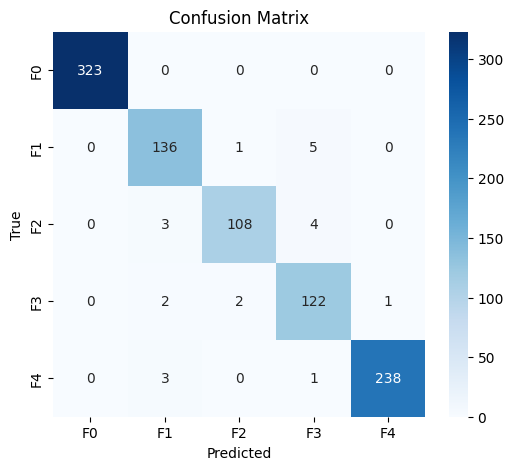

In [47]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

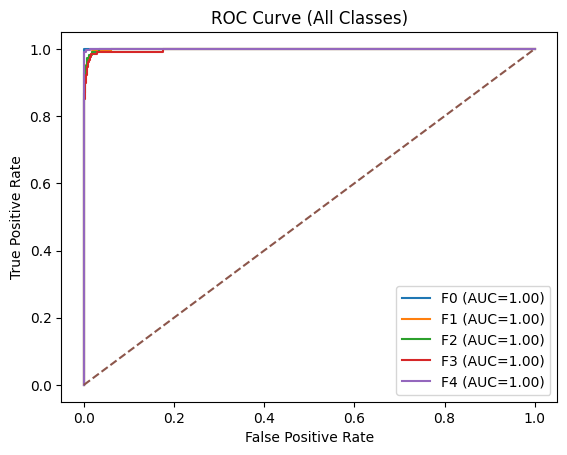

In [48]:
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])

plt.figure()

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    auc_score = roc_auc_score(y_true_bin[:,i], y_prob[:,i])

    plt.plot(fpr, tpr, label=f"F{i} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Classes)")
plt.legend()

plt.show()

In [49]:
mean_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr")

print("Mean ROC AUC:", mean_auc)

Mean ROC AUC: 0.9990289726644154


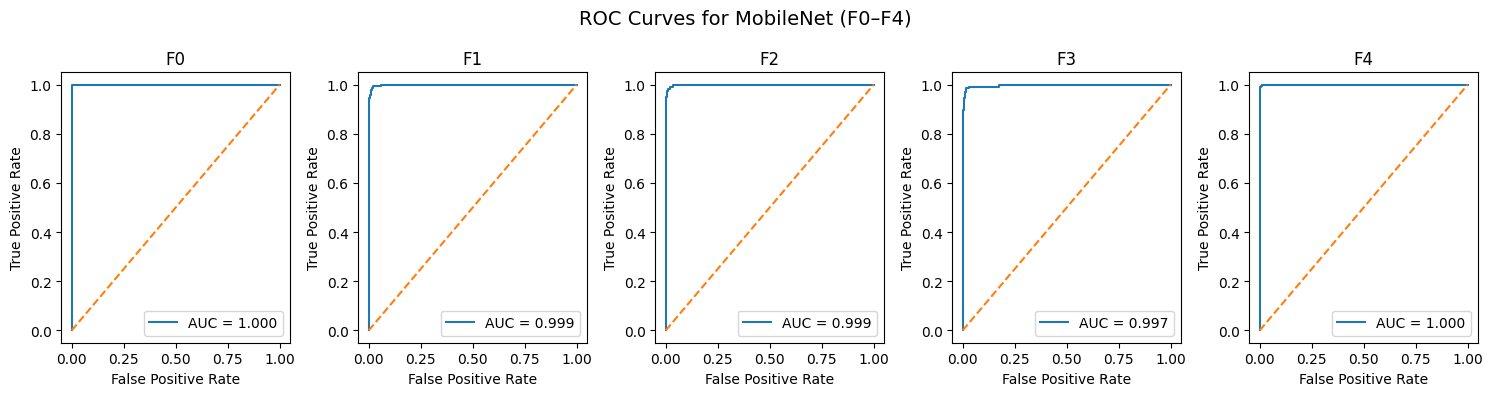

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])

class_names = ["F0","F1","F2","F3","F4"]

plt.figure(figsize=(15,4))

for i in range(5):

    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    auc_score = roc_auc_score(y_true_bin[:,i], y_prob[:,i])

    plt.subplot(1,5,i+1)

    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1],[0,1],'--')  # diagonal

    plt.title(class_names[i])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

plt.suptitle("ROC Curves for MobileNet (F0–F4)", fontsize=14)
plt.tight_layout()

plt.show()

In [51]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=24495d7ae856aae70d66b3680de376c2670576115c1f5cabebbcfe3aa8f20031
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [52]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [53]:
target_layer = model.features[-1]

In [54]:
def visualize_cam(img_tensor, label):

    model.eval()

    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Convert to numpy image
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    # GradCAM++
    cam1 = GradCAMPlusPlus(model=model, target_layers=[target_layer])
    grayscale_cam1 = cam1(input_tensor=input_tensor)[0]
    cam_image1 = show_cam_on_image(img, grayscale_cam1, use_rgb=True)

    # ScoreCAM
    cam2 = ScoreCAM(model=model, target_layers=[target_layer])
    grayscale_cam2 = cam2(input_tensor=input_tensor)[0]
    cam_image2 = show_cam_on_image(img, grayscale_cam2, use_rgb=True)

    return img, cam_image1, cam_image2

In [55]:
class_images = {}

for img, label in test_dataset:
    if label not in class_images:
        class_images[label] = img

    if len(class_images) == 5:
        break

100%|██████████| 80/80 [00:22<00:00,  3.53it/s]


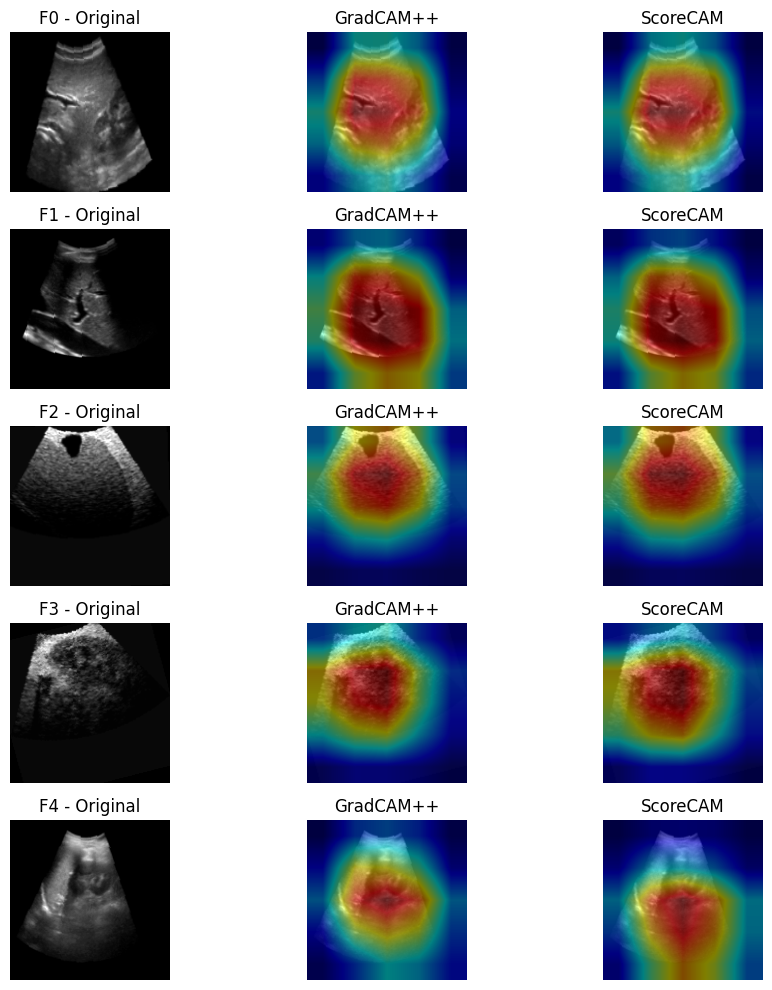

In [56]:
plt.figure(figsize=(10,10))

class_names = ["F0","F1","F2","F3","F4"]

for i in range(5):

    img_tensor = class_images[i]

    orig, gradcam, scorecam = visualize_cam(img_tensor, i)

    # Original
    plt.subplot(5,3,i*3+1)
    plt.imshow(orig)
    plt.title(f"{class_names[i]} - Original")
    plt.axis('off')

    # GradCAM++
    plt.subplot(5,3,i*3+2)
    plt.imshow(gradcam)
    plt.title("GradCAM++")
    plt.axis('off')

    # ScoreCAM
    plt.subplot(5,3,i*3+3)
    plt.imshow(scorecam)
    plt.title("ScoreCAM")
    plt.axis('off')

plt.tight_layout()
plt.show()

100%|██████████| 80/80 [00:24<00:00,  3.26it/s]


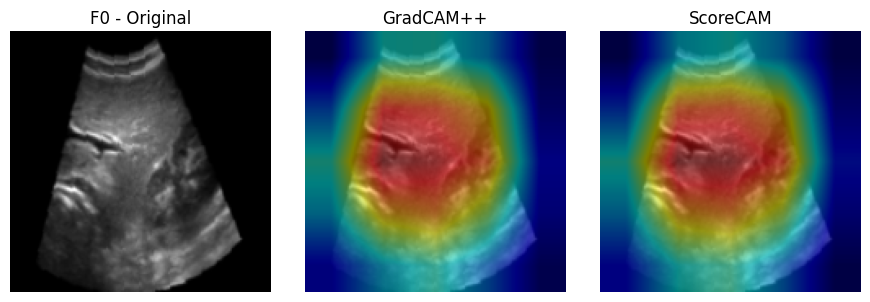

100%|██████████| 80/80 [00:22<00:00,  3.53it/s]


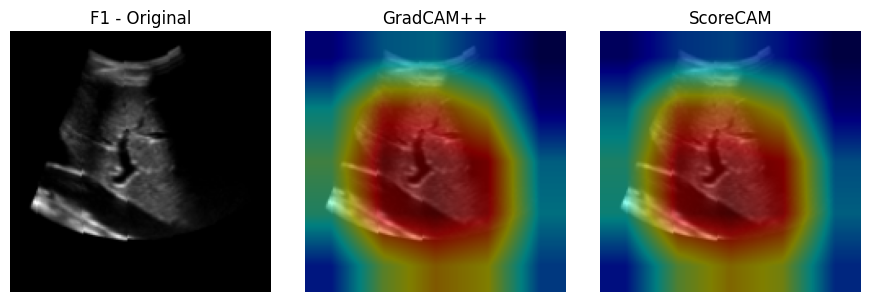

100%|██████████| 80/80 [00:21<00:00,  3.68it/s]


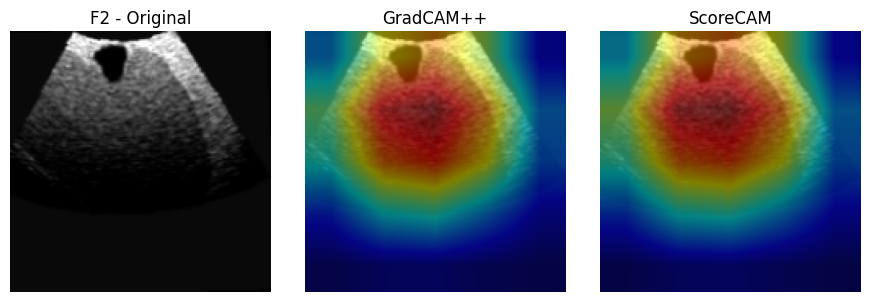

100%|██████████| 80/80 [00:22<00:00,  3.51it/s]


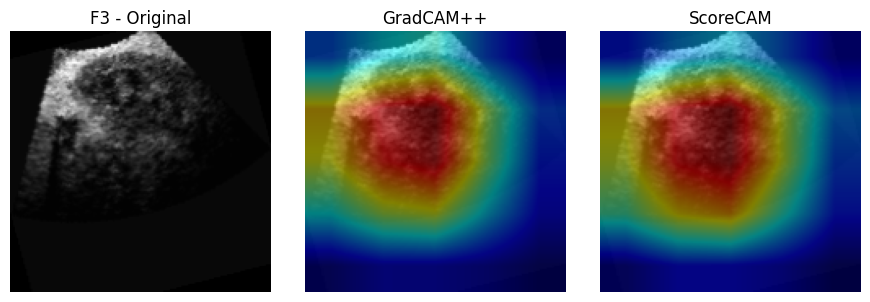

100%|██████████| 80/80 [00:24<00:00,  3.30it/s]


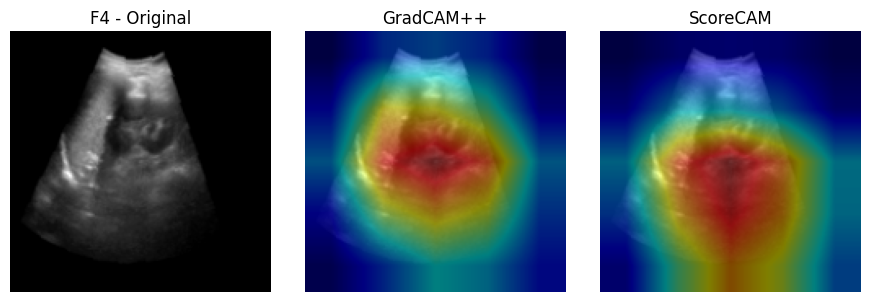

In [58]:
class_names = ["F0","F1","F2","F3","F4"]

for i in range(5):

    img_tensor = class_images[i]
    orig, gradcam, scorecam = visualize_cam(img_tensor, i)

    plt.figure(figsize=(9,3))   # 👈 THIS is your perfect size

    # Original
    plt.subplot(1,3,1)
    plt.imshow(orig)
    plt.title(f"{class_names[i]} - Original", fontsize=12)
    plt.axis('off')

    # GradCAM++
    plt.subplot(1,3,2)
    plt.imshow(gradcam)
    plt.title("GradCAM++", fontsize=12)
    plt.axis('off')

    # ScoreCAM
    plt.subplot(1,3,3)
    plt.imshow(scorecam)
    plt.title("ScoreCAM", fontsize=12)
    plt.axis('off')

    plt.tight_layout()

    # 🔥 SAVE (VERY IMPORTANT FOR REPORT)
    plt.savefig(f"{class_names[i]}_XAI.png", dpi=300, bbox_inches='tight')

    plt.show()